<a href="https://colab.research.google.com/github/lorenzo1285/nlp/blob/main/item_cluster_103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalacion de librerias

In [ ]:
!pip install jellyfish
!pip install bertopic
!pip install fuzzywuzzy
!pip install ydata-profiling

# Importación de Paqueterías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jellyfish as jf
import nltk
import re

from ydata_profiling import ProfileReport
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from bertopic import BERTopic
from scipy.cluster import hierarchy as sch
from umap import UMAP
from hdbscan import HDBSCAN
from wordcloud import WordCloud
from fuzzywuzzy import process
from nltk.corpus import stopwords
nltk.download('stopwords')

pd.options.display.max_rows = 9999
pd.set_option("display.max_columns", None)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Definición de Funciones

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def get_n_words(corpus, direction, n):
    stop_words_es = ['el', 'la', 'los', 'las', 'de', 'del', 'que', 'y', 'a', 'en', 'un', 'una', 'para', 'por', 'con']
    vec = CountVectorizer(stop_words = stop_words_es).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    if direction == "top":
        words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    else:
        words_freq =sorted(words_freq, key = lambda x: x[1], reverse=False)
    return words_freq[:n]

In [ ]:
def remove_stopwords(text):
    stop_words = ['el', 'la', 'los', 'las', 'de', 'del', 'que', 'y', 'a', 'en', 'un', 'una', 'para', 'por', 'con']
    words = text.split()
    clean_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(clean_words)

# Importación de datos

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/materiales_soriana/materiales_104.csv')
df.head()

,EMATN,MATNR,MATNR_ekbe_1,Material_mbew_1,TXZ01,Denominacion_2_del_gr_articulos,Denominacion_GrpComp,ITEM,TEXT_FOR_ITEM_CAT,grupo,categoria_de_compra,sub_categoria_de_compra,modelo_de_compra
0,11617692.0,11617692.0,11617692.0,11617692.0,SUBSCRIBERS HYS,SERVICIOS PROFESIONALES,EcomMKTyUX,0.0,STANDARD,SERVICIOS PROFESIONALES,PUBLICIDAD Y MERCADOTECNIA,MEDIOS Y ANUNCIOS,SERVICIOS CON TARIFAS PERIODICAS
1,11053368.0,11053368.0,11053368.0,11053368.0,COMISION PROGRAMA DE LEALTAD,SERVICIOS PROFESIONALES,Programas de Lealt,0.0,STANDARD,SERVICIOS PROFESIONALES,PUBLICIDAD Y MERCADOTECNIA,PROMOCIONES,SERVICIOS PROFESIONALES Y ESPECIALIZADOS
2,11663824.0,11663824.0,11663824.0,11663824.0,SERVICIO CONSULTORIA,OTROS,GstComisprovmp,0.0,STANDARD,NaN,NaN,NaN,NaN
3,3041702.0,3041702.0,NaN,NaN,PAPEL HIGIENICO COTTONELLE 40/180 HOJAS,PRODUCTOS DE PAPEL PARA EL HOGAR,Higien-Desech-Masc,7.0,STOCK TRANSFER,NaN,NaN,NaN,NaN
4,3013747.0,3013747.0,NaN,NaN,BLANQUEADOR MULTIEMPAQUE 15 500 M,CLOROS Y DESINFECTANTES,Higien-Desech-Masc,7.0,STOCK TRANSFER,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44791 entries, 0 to 44790
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   EMATN                            44789 non-null  float64
 1   MATNR                            44789 non-null  float64
 2   MATNR_ekbe_1                     33917 non-null  float64
 3   Material_mbew_1                  13375 non-null  float64
 4   TXZ01                            44788 non-null  object 
 5   Denominacion_2_del_gr_articulos  44786 non-null  object 
 6   Denominacion_GrpComp             44791 non-null  object 
 7   ITEM                             44789 non-null  float64
 8   TEXT_FOR_ITEM_CAT                44789 non-null  object 
 9   grupo                            10343 non-null  object 
 10  categoria_de_compra              10343 non-null  object 
 11  sub_categoria_de_compra          10312 non-null  object 
 12  modelo_de_compra  

# Procesamiento de Datos

In [ ]:
df['TXZ01'].duplicated(keep=False).value_counts()

True     28649
False    16142
Name: TXZ01, dtype: int64

In [ ]:
df['EMATN'].duplicated(keep=False).value_counts()

True     32629
False    12162
Name: EMATN, dtype: int64

In [ ]:
material = df.drop_duplicates(subset=['EMATN'], keep=False)
material.shape

(12162, 13)

In [ ]:
material.isnull().sum().sort_values(ascending=False)

sub_categoria_de_compra            6424
grupo                              6422
categoria_de_compra                6422
modelo_de_compra                   6422
Material_mbew_1                    4684
MATNR_ekbe_1                        968
EMATN                                 0
MATNR                                 0
TXZ01                                 0
Denominacion_2_del_gr_articulos       0
Denominacion_GrpComp                  0
ITEM                                  0
TEXT_FOR_ITEM_CAT                     0
dtype: int64

In [ ]:
# material = material.dropna()
# material.isnull().sum().sort_values(ascending=False)

EMATN                              0
TXZ01                              0
Denominacion_2_del_gr_articulos    0
Denominacion_GrpComp               0
dtype: int64

In [ ]:
categories = len(df['Denominacion_2_del_gr_articulos'].value_counts())
print(f'Numero de categorias {categories}')

Numero de categorias 238


In [ ]:
profile = ProfileReport(df,
                        title="Análisis Exploratorio de Datos Materiales Soriana",
                                dataset={
        "descripción": "Reporte generado con la finalidad de análizar la calidad de los materiales registrados en SAP",
    }

                          )
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile.to_file("Analysis.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df.loc[df['EMATN'] == 0].count()

EMATN                              5714
MATNR                              5714
MATNR_ekbe_1                       4980
Material_mbew_1                       0
TXZ01                              5714
Denominacion_2_del_gr_articulos    5711
Denominacion_GrpComp               5714
ITEM                               5714
TEXT_FOR_ITEM_CAT                  5714
grupo                                 0
categoria_de_compra                   0
sub_categoria_de_compra               0
modelo_de_compra                      0
dtype: int64

In [ ]:
df['EMATN'].duplicated().value_counts()

True     24936
False    19855
Name: EMATN, dtype: int64

In [ ]:
non_duplicated = df.drop_duplicates(subset=['EMATN'])
non_duplicated.shape

(19855, 13)

In [ ]:
material = df.drop_duplicates(subset=['EMATN'], keep=False)
material.shape

(12162, 13)

In [ ]:
stop_words = set(stopwords.words('spanish') +
                 ['el', 'la', 'los', 'las', 'de', 'del', 'que', 'y', 'a', 'en', 'un', 'una', 'para', 'por', 'con'])

material['TXZ01'] = material['TXZ01'].apply(lambda x: remove_stopwords(x))

In [ ]:
material['material_clean'] = material['TXZ01'].str.lower()

material.head()

,EMATN,MATNR,MATNR_ekbe_1,Material_mbew_1,TXZ01,Denominacion_2_del_gr_articulos,Denominacion_GrpComp,ITEM,TEXT_FOR_ITEM_CAT,grupo,categoria_de_compra,sub_categoria_de_compra,modelo_de_compra,material_clean
0,11617692.0,11617692.0,11617692.0,11617692.0,SUBSCRIBERS HYS,SERVICIOS PROFESIONALES,EcomMKTyUX,0.0,STANDARD,SERVICIOS PROFESIONALES,PUBLICIDAD Y MERCADOTECNIA,MEDIOS Y ANUNCIOS,SERVICIOS CON TARIFAS PERIODICAS,subscribers hys
1,11053368.0,11053368.0,11053368.0,11053368.0,COMISION PROGRAMA LEALTAD,SERVICIOS PROFESIONALES,Programas de Lealt,0.0,STANDARD,SERVICIOS PROFESIONALES,PUBLICIDAD Y MERCADOTECNIA,PROMOCIONES,SERVICIOS PROFESIONALES Y ESPECIALIZADOS,comision programa lealtad
2,11663824.0,11663824.0,11663824.0,11663824.0,SERVICIO CONSULTORIA,OTROS,GstComisprovmp,0.0,STANDARD,NaN,NaN,NaN,NaN,servicio consultoria
4,3013747.0,3013747.0,NaN,NaN,BLANQUEADOR MULTIEMPAQUE 15 500 M,CLOROS Y DESINFECTANTES,Higien-Desech-Masc,7.0,STOCK TRANSFER,NaN,NaN,NaN,NaN,blanqueador multiempaque 15 500 m
69,11548809.0,11548809.0,11548809.0,11548809.0,LICENCIA 2020,PARTES Y REFACCIONES EQ DE SEGURIDAD,SOD Sistemas,0.0,STANDARD,ACTIVOS E INVERSIONES EN CURSO,EQUIPO DE COMPUTO Y TELECOMUNICACIONES,ACTIVOS E INVERSIONES EN CURSO,MOBILIARIO Y EQUIPO,licencia 2020


In [ ]:
txt = material['material_clean'].to_list()
txt[:5]

['subscribers hys',
 'comision programa lealtad',
 'servicio consultoria',
 'blanqueador multiempaque 15 500 m',
 'licencia 2020']

In [ ]:
txt = [re.sub(r'[^a-zA-Z0-9\s]+', '', x) for x in txt]

In [ ]:
# txt = [str(elemento) for elemento in txt]
# txt = [re.sub(r'[^\w\s]', '', elemento) for elemento in txt]

In [ ]:
txt[:5]

['subscribers hys',
 'comision programa lealtad',
 'servicio consultoria',
 'blanqueador multiempaque 15 500 m',
 'licencia 2020']

In [ ]:
material['material_clean'] = txt
material.head()

,EMATN,MATNR,MATNR_ekbe_1,Material_mbew_1,TXZ01,Denominacion_2_del_gr_articulos,Denominacion_GrpComp,ITEM,TEXT_FOR_ITEM_CAT,grupo,categoria_de_compra,sub_categoria_de_compra,modelo_de_compra,material_clean
0,11617692.0,11617692.0,11617692.0,11617692.0,SUBSCRIBERS HYS,SERVICIOS PROFESIONALES,EcomMKTyUX,0.0,STANDARD,SERVICIOS PROFESIONALES,PUBLICIDAD Y MERCADOTECNIA,MEDIOS Y ANUNCIOS,SERVICIOS CON TARIFAS PERIODICAS,subscribers hys
1,11053368.0,11053368.0,11053368.0,11053368.0,COMISION PROGRAMA LEALTAD,SERVICIOS PROFESIONALES,Programas de Lealt,0.0,STANDARD,SERVICIOS PROFESIONALES,PUBLICIDAD Y MERCADOTECNIA,PROMOCIONES,SERVICIOS PROFESIONALES Y ESPECIALIZADOS,comision programa lealtad
2,11663824.0,11663824.0,11663824.0,11663824.0,SERVICIO CONSULTORIA,OTROS,GstComisprovmp,0.0,STANDARD,NaN,NaN,NaN,NaN,servicio consultoria
4,3013747.0,3013747.0,NaN,NaN,BLANQUEADOR MULTIEMPAQUE 15 500 M,CLOROS Y DESINFECTANTES,Higien-Desech-Masc,7.0,STOCK TRANSFER,NaN,NaN,NaN,NaN,blanqueador multiempaque 15 500 m
69,11548809.0,11548809.0,11548809.0,11548809.0,LICENCIA 2020,PARTES Y REFACCIONES EQ DE SEGURIDAD,SOD Sistemas,0.0,STANDARD,ACTIVOS E INVERSIONES EN CURSO,EQUIPO DE COMPUTO Y TELECOMUNICACIONES,ACTIVOS E INVERSIONES EN CURSO,MOBILIARIO Y EQUIPO,licencia 2020


In [ ]:
material.sample(10)

,EMATN,MATNR,MATNR_ekbe_1,Material_mbew_1,TXZ01,Denominacion_2_del_gr_articulos,Denominacion_GrpComp,ITEM,TEXT_FOR_ITEM_CAT,grupo,categoria_de_compra,sub_categoria_de_compra,modelo_de_compra,material_clean
27468,11501101.0,11501101.0,11501101.0,11501101.0,Telefonia CEDIS CAPLAN,SERVICIOS PROFESIONALES,SOD Sistemas,0.0,STANDARD,SERVICIOS PUBLICOS Y GENERALES,SERVICIOS TECNOLOGÍAS DE LA INFORMACIÓN,SERVICIOS TELECOMUNICACIONES,SERVICIOS TELECOMUNICACIONES,telefonia cedis caplan
2389,11505010.0,11505010.0,11505010.0,11505010.0,CABALLETE TROVICEL 3 mm 8 x 30 cm,OTROS,Programas de Lealt,0.0,STANDARD,SERVICIOS PROFESIONALES,PUBLICIDAD Y MERCADOTECNIA,PROMOCIONES,SERVICIOS PROFESIONALES Y ESPECIALIZADOS,caballete trovicel 3 mm 8 x 30 cm
37766,6260148.0,6260148.0,6260148.0,6260148.0,EMPAQUE 17-44126-00 CABEZA LAT DESCARGAD,MATTO. CORRECTIVO TRANSPORTE PESADO,Trans CADVilla Ind,0.0,STANDARD,MANTENIMIENTO,SERVICIOS Y GASTOS DE MANTENIMIENTO,MANTENIMIENTO FLOTA Y EQUIPO DE TRANSPORTE,"PM_SERVICIOS DE MANTENIMIENTO, PARTES Y REFACC...",empaque 174412600 cabeza lat descargad
33646,11650461.0,11650461.0,11650461.0,11650461.0,PAGO SDV PROYECTOS SISTEMAS,SERVICIOS PROFESIONALES,SOD Rec Humanos,0.0,STANDARD,SERVICIOS PROFESIONALES,"SERVICIOS FINANCIEROS, JURÍDICOS Y NORMATIVOS",SEGUROS Y FIANZAS,SERVICIOS PROFESIONALES Y ESPECIALIZADOS,pago sdv proyectos sistemas
12569,11419013.0,11419013.0,11419013.0,11419013.0,CARGADOR TIPO 1,MATTO. CORRECTIVO TRANSPORTE PESADO,Trans CAD Qro Ind,0.0,STANDARD,MANTENIMIENTO,SERVICIOS Y GASTOS DE MANTENIMIENTO,MANTENIMIENTO FLOTA Y EQUIPO DE TRANSPORTE,"PM_SERVICIOS DE MANTENIMIENTO, PARTES Y REFACC...",cargador tipo 1
20422,6254821.0,6254821.0,6254821.0,NaN,ANUNCIO CORAZON SORIANA 2.78 MTS,LOGOTIPO Y LEYENDA EN FACHADA,Mantenimiento,0.0,STANDARD,NaN,NaN,NaN,NaN,anuncio corazon soriana 278 mts
22804,11671773.0,11671773.0,11671773.0,11671773.0,2022-DUSTER-Q122798-1994S,OTROS,Logistica y Transp,0.0,STANDARD,ARRENDAMIENTOS,ARRENDAMIENTO DE EQUIPO Y TRANSPORTE,ARRENDAMIENTO DE EQUIPO Y TRANSPORTE,ARRENDAMIENTO MOBILIARIO Y EQUIPO,2022dusterq1227981994s
1714,11552410.0,11552410.0,11552410.0,11552410.0,HPE Proactive Care CTR SVCPROLIANT BL460,SERVICIOS VARIOS R6%,Sop Técnico Sistem,0.0,STANDARD,MANTENIMIENTO,"PARTES, REFACCIONES Y HERRAMIENTAS",MANTENIMIENTO DE EQUIPO DE COMPUTO,MATERIALES Y HERRAMIENTAS NO INVENTARIABLES,hpe proactive care ctr svcproliant bl460
4944,11153427.0,11153427.0,11153427.0,11153427.0,Stopper 30x15cms cartulina Carolina 16pt,OTROS,Impresos,0.0,STANDARD,INSUMOS OPERACIÓN Y MERCADEO,PUBLICIDAD Y MERCADOTECNIA,ARTICULOS PUBLICITARIOS,MATRIALES MAQUILADOS,stopper 30x15cms cartulina carolina 16pt
41952,11684487.0,11684487.0,11684487.0,NaN,INSTALACIÓN CÁMARA CONGELADOS,EQUIPO REFRIGERACION,Refrig Comer C y C,0.0,STANDARD,NaN,NaN,NaN,NaN,instalacin cmara congelados


In [ ]:
material.shape

(12162, 14)

# Exploratorio de Datos

In [ ]:
common_words = get_n_words(material['material_clean'], "top", 15)
rare_words = get_n_words(material['material_clean'], "bottom", 15)

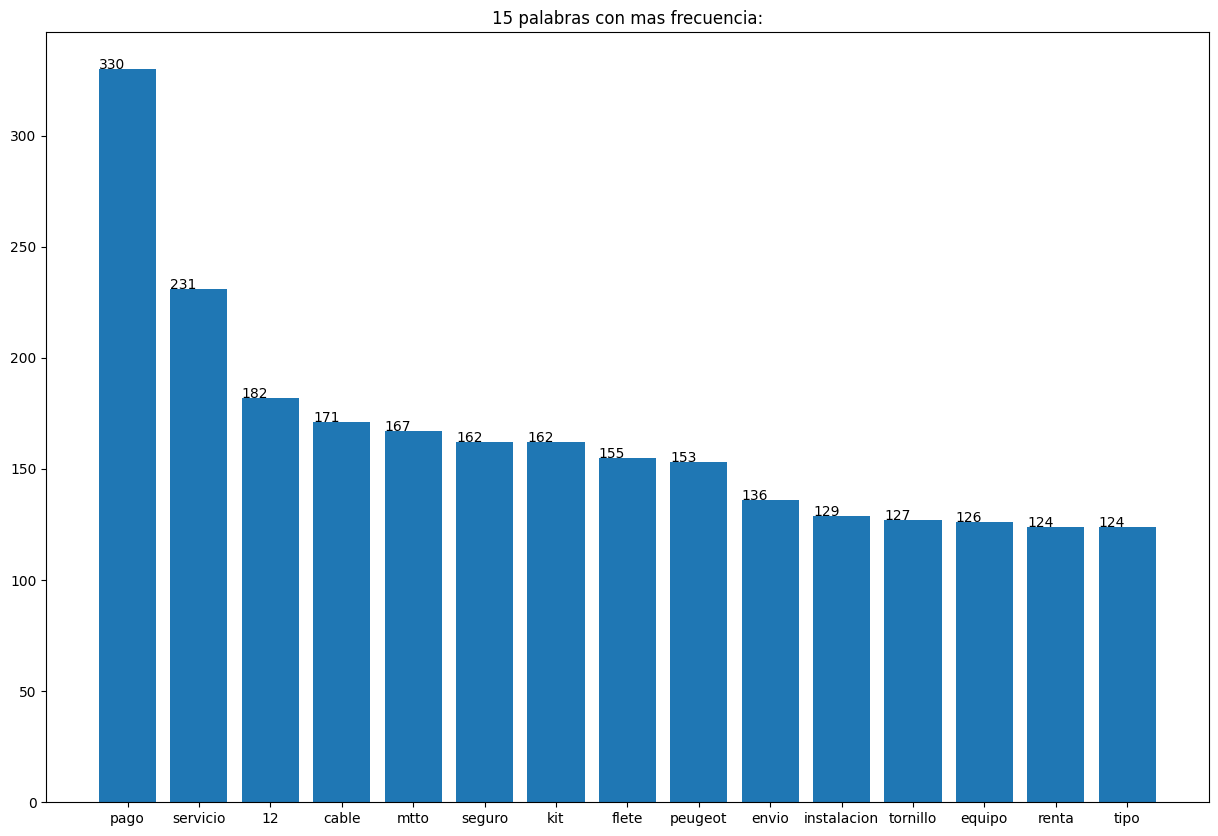

In [ ]:
common_words = dict(common_words)
names = list(common_words.keys())
values = list(common_words.values())
plt.subplots(figsize = (15,10))
bars = plt.bar(range(len(common_words)),values,tick_label=names)
plt.title('15 palabras con mas frecuencia:')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + .01, yval)
plt.show()

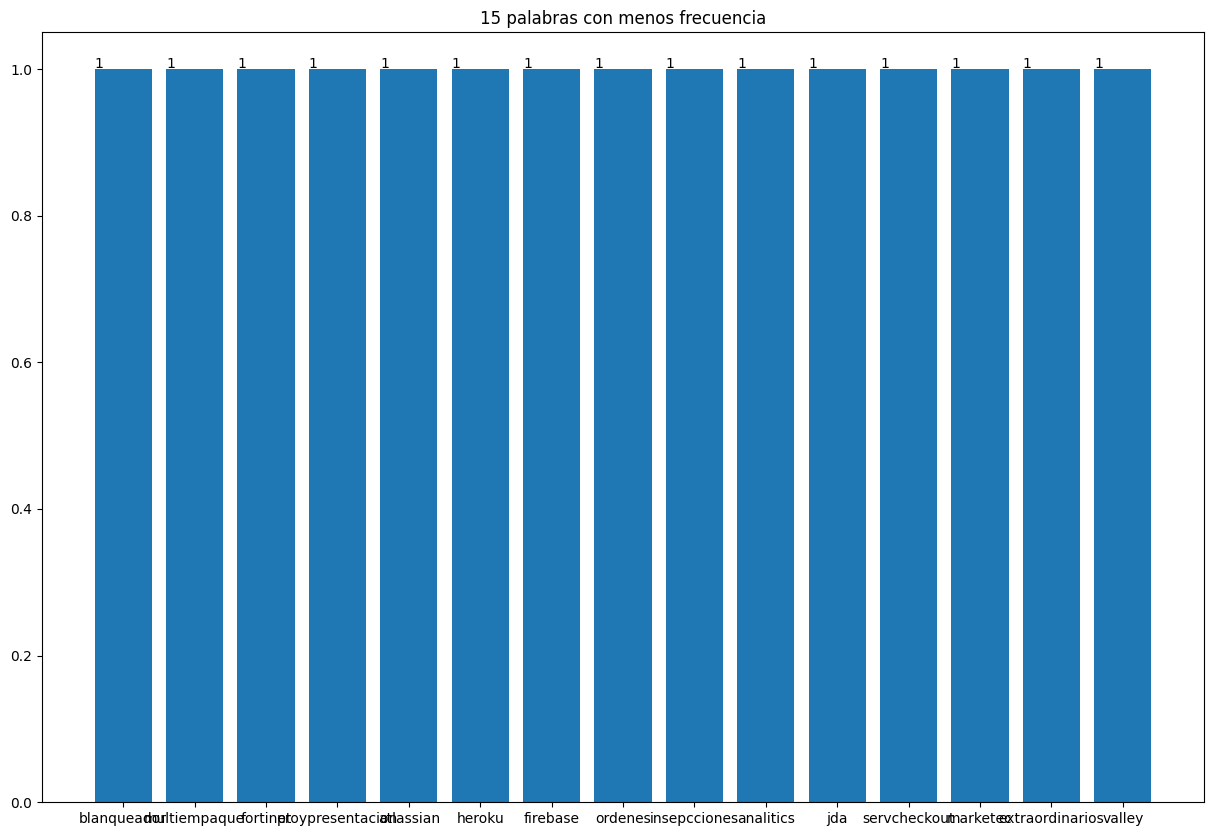

In [ ]:
rare_words = dict(rare_words)
names = list(rare_words.keys())
values = list(rare_words.values())
plt.subplots(figsize = (15,10))
bars = plt.bar(range(len(rare_words)),values,tick_label=names)
plt.title('15 palabras con menos frecuencia')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + .001, yval)
plt.show()

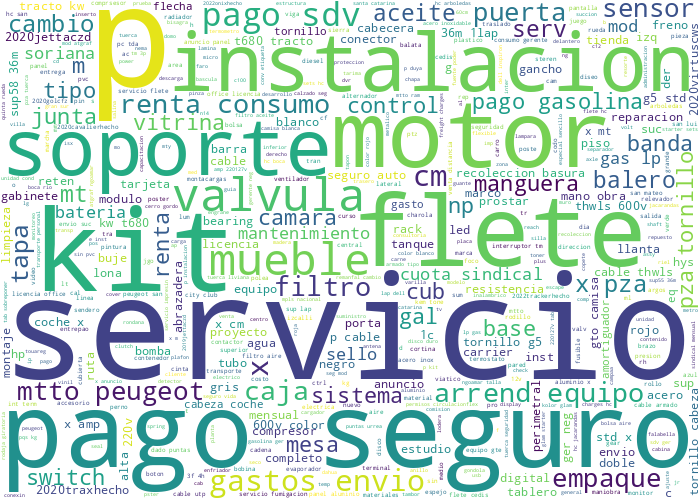

In [ ]:
long_string = ','.join(list(material['material_clean'].values))
wordcloud = WordCloud(background_color="white", max_words=5000, width=700, height=500, contour_width=10, contour_color='steelblue')
wordcloud.generate(long_string)
wordcloud.to_image()

Numero de palabras por item

count    12162.000000
mean         3.944088
std          1.722362
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         10.000000
Name: material_clean, dtype: float64


<Axes: >

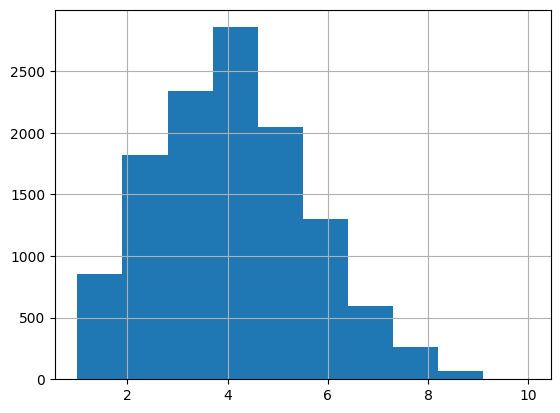

In [ ]:
lens = material['material_clean'].str.split().apply(lambda x: len(x))
print(lens.describe())
lens.hist()

# Modelo topic modeling

In [ ]:
mat_list = material['material_clean'].to_list()

In [ ]:
model = BERTopic(language="multilingual",
                 calculate_probabilities=True,
                 )

topics, probs = model.fit_transform(mat_list)

linkage_function = lambda x: sch.linkage(x, 'centroid', optimal_ordering=True)
distance_function = lambda x: np.abs(1 - cosine_similarity(x))

In [ ]:
hierarchical_topics = model.hierarchical_topics(
                                                    mat_list,
                                                    linkage_function=linkage_function,
                                                    distance_function=distance_function
                                                    )

100%|██████████| 285/285 [00:05<00:00, 50.86it/s]


In [ ]:
hierarchical_topics.head()

,Parent_ID,Parent_Name,Topics,Child_Left_ID,Child_Left_Name,Child_Right_ID,Child_Right_Name,Distance
284,570,2020versahr16994133t852_2020versahr16978069t87...,[285],285,2020versahr16994133t852_2020versahr16978069t87...,569,2021forteg4nhme4447361571s_2021forteg4nhme4422...,0.710405
283,569,2021forteg4nhme4447361571s_2021forteg4nhme4422...,[267],568,2021forteg4nhme4447361571s_2021forteg4nhme4422...,276,2021sportageg4nalw6406591258s_2021sportageg4na...,0.710423
282,568,2021forteg4nhme4447361571s_2021forteg4nhme4422...,[267],267,2021forteg4nhme4447361571s_2021forteg4nhme4422...,567,2020riog4fgle0206361117_2020riog4fgle006507959...,0.710442
281,567,2020riog4fgle0206361117_2020riog4fgle006507959...,[230],566,2020riog4fgle0206361117_2020riog4fgle006507959...,258,2019jettaczd_924592542s_924576545s_924550553s_...,0.710462
280,566,2020riog4fgle0206361117_2020riog4fgle006507959...,[230],230,2020riog4fgle0206361117_2020riog4fgle006507959...,565,2020kickshr16206424v1233s_2020kickshr16891062t...,0.710481


In [ ]:
info = model.get_topic_info()
info['Count'].sum()

12162

In [ ]:
info.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3079,-1_flete_soporte_soriana_servicio,"[flete, soporte, soriana, servicio, mts, tipo,...","[rampa movil 365 mts rec vert 2do pago, sup 91..."
1,0,653,0_peugeot_empaque_rondana_cruceta,"[peugeot, empaque, rondana, cruceta, valv, jun...","[valv bola 118 emerson abv9, valv bola 58 emer..."
2,1,300,1_pago_seguro_sdv_auto,"[pago, seguro, sdv, auto, ger, neg, vida, proy...","[pago sdv ger neg construccion, pago sdv ger n..."
3,2,154,2_gratificacion_campaa_seccionado_hotjar,"[gratificacion, campaa, seccionado, hotjar, oj...","[gratificacion arrendamiento falabella, gratif..."
4,3,147,3_cable_armado_cal_hilos,"[cable, armado, cal, hilos, thw, hdmi, desnudo...","[sum tendido cable thw cal 6 3 hilos, cable ar..."


In [ ]:
tree = model.get_topic_tree(hierarchical_topics)
print(tree)

.
├─■──2020versahr16994133t852_2020versahr16978069t870_2020versahr16970813t699_2020versahr16970806t778_2020 ── Topic: 285
└─2021forteg4nhme4447361571s_2021forteg4nhme4422741517s_2021forteg4nhme4023711475s_2021forteg4nhme4022
     ├─2021forteg4nhme4447361571s_2021forteg4nhme4422741517s_2021forteg4nhme4023711475s_2021forteg4nhme4022
     │    ├─■──2021forteg4nhme4447361571s_2021forteg4nhme4422741517s_2021forteg4nhme4023711475s_2021forteg4nhme4022 ── Topic: 267
     │    └─2020riog4fgle0206361117_2020riog4fgle006507959_2020riog4fgkh738672516_2020riog4fgkh738115535_2020rio
     │         ├─2020riog4fgle0206361117_2020riog4fgle006507959_2020riog4fgkh738672516_2020riog4fgkh738115535_2020rio
     │         │    ├─■──2020riog4fgle0206361117_2020riog4fgle006507959_2020riog4fgkh738672516_2020riog4fgkh738115535_2020rio ── Topic: 230
     │         │    └─2020kickshr16206424v1233s_2020kickshr16891062t895s_2020kickshr16919523t854s_2020kickshr16917910t704s
     │         │         ├─2020kickshr16206

In [ ]:
model.visualize_hierarchy(hierarchical_topics=hierarchical_topics,
                          linkage_function=linkage_function,
                            distance_function=distance_function
                          )

In [ ]:
model.get_topic(0)

[('peugeot', 0.013522278158079272),
 ('empaque', 0.010886586988399671),
 ('rondana', 0.010654064023729027),
 ('cruceta', 0.009864196435821756),
 ('valv', 0.009400515379600904),
 ('junta', 0.009383611957057936),
 ('plafon', 0.009335028211197477),
 ('seal', 0.009229969352828566),
 ('tuerca', 0.008946273400932495),
 ('tapa', 0.008833426214180155)]

In [ ]:
model.get_representative_docs(0)

['valv bola 118 emerson abv9',
 'valv bola 58 emerson abv5',
 'empaque 4026507 tapa val cummins']

In [ ]:
model.get_topic(0, full=True)

{'Main': [('peugeot', 0.013522278158079272),
  ('empaque', 0.010886586988399671),
  ('rondana', 0.010654064023729027),
  ('cruceta', 0.009864196435821756),
  ('valv', 0.009400515379600904),
  ('junta', 0.009383611957057936),
  ('plafon', 0.009335028211197477),
  ('seal', 0.009229969352828566),
  ('tuerca', 0.008946273400932495),
  ('tapa', 0.008833426214180155)]}

In [ ]:
model.get_topic(1)

[('pago', 0.07447820171824782),
 ('seguro', 0.07044359938723622),
 ('sdv', 0.06966903548894572),
 ('auto', 0.04143945712745091),
 ('ger', 0.035597393325749266),
 ('neg', 0.028781878850711463),
 ('vida', 0.02660307967636681),
 ('proyectos', 0.014489876226165859),
 ('admin', 0.014446365787972676),
 ('mad', 0.01394583189712967)]

In [ ]:
model.get_representative_docs(1)

['pago sdv ger neg construccion',
 'pago sdv ger neg pintura',
 'pago seguro auto ger neg construccion']

In [ ]:
model.visualize_barchart(top_n_topics=12)

In [ ]:
model.visualize_topics()

In [ ]:
model.visualize_heatmap(top_n_topics=20)

In [ ]:
model.visualize_hierarchy(top_n_topics=20)

In [ ]:
model.get_representative_docs(1)

['pago sdv ger neg construccion',
 'pago sdv ger neg pintura',
 'pago seguro auto ger neg construccion']

In [ ]:
model.get_topic(1)

[('pago', 0.07447820171824782),
 ('seguro', 0.07044359938723622),
 ('sdv', 0.06966903548894572),
 ('auto', 0.04143945712745091),
 ('ger', 0.035597393325749266),
 ('neg', 0.028781878850711463),
 ('vida', 0.02660307967636681),
 ('proyectos', 0.014489876226165859),
 ('admin', 0.014446365787972676),
 ('mad', 0.01394583189712967)]

In [ ]:
model.visualize_documents(mat_list,
                          #reduced_embeddings=reduced_embeddings,
                          hide_document_hover=True,
                          hide_annotations=True)

In [ ]:
model.visualize_term_rank()

In [ ]:
topic_distr, _ = model.approximate_distribution(mat_list)
model.visualize_distribution(topic_distr[1])

In [ ]:
model.get_representative_docs(4)

['2022t cross248411786',
 '2022t crossdbt02972231955',
 '2022t crossdtb0293441952']

# Comparacion de items

In [ ]:
resultado = process.extract('pago',
                material['material_clean'],
                limit=None,
                #scorer=jf.jaro_winkler_similarity,
                )

resultado_df  = pd.DataFrame(resultado, columns=['material', 'score', 'index'])
resultado_df[['material', 'score']].value_counts().to_frame()

,,0
material,score,
gastos envio,45,50
gas lp,36,30
sindicato,45,17
recoleccion basura,22,15
medios,22,13
...,...,...
envios,22,1
envios 2,22,1
envo clubes,22,1


In [ ]:
resultado_df.shape

(12162, 3)

In [ ]:
resultados_filtrados = list(filter(lambda x: x[1] >= 80, resultado))

resultados_filtrados = pd.DataFrame(resultados_filtrados, columns=['material', 'score', 'index'])

resultados_filtrados[['material', 'score']].value_counts().to_csv('tema_2.csv')

In [ ]:
resultados_filtrados.shape

(1885, 3)

In [ ]:
hierarchical_topics.head()

,Parent_ID,Parent_Name,Topics,Child_Left_ID,Child_Left_Name,Child_Right_ID,Child_Right_Name,Distance
231,464,rsoedifeexttpatoetdsdro_coproparasitoscopia_21...,[196],196,rsoedifeexttpatoetdsdro_coproparasitoscopia_21...,463,seguro_mensajeria_eq_computo_,0.714701
230,463,seguro_mensajeria_eq_computo_,[91],462,seguro_mensajeria_eq_computo_,195,residuales_final_extrac_dispo_aguas,0.714760
229,462,seguro_mensajeria_eq_computo_,[91],91,seguro_mensajeria_eq_computo_,461,perifoneo_hora___,0.714820
228,461,perifoneo_hora___,[10],460,perifoneo_hora___,16,md_lser_kimpresin__,0.714881
227,460,perifoneo_hora___,[10],10,perifoneo_hora___,459,temperaturas_nom015stps2001_eval_nom015stps_ex...,0.714942


In [ ]:
model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3079,-1_flete_soporte_soriana_servicio,"[flete, soporte, soriana, servicio, mts, tipo,...","[rampa movil 365 mts rec vert 2do pago, sup 91..."
1,0,653,0_peugeot_empaque_rondana_cruceta,"[peugeot, empaque, rondana, cruceta, valv, jun...","[valv bola 118 emerson abv9, valv bola 58 emer..."
2,1,300,1_pago_seguro_sdv_auto,"[pago, seguro, sdv, auto, ger, neg, vida, proy...","[pago sdv ger neg construccion, pago sdv ger n..."
3,2,154,2_gratificacion_campaa_seccionado_hotjar,"[gratificacion, campaa, seccionado, hotjar, oj...","[gratificacion arrendamiento falabella, gratif..."
4,3,147,3_cable_armado_cal_hilos,"[cable, armado, cal, hilos, thw, hdmi, desnudo...","[sum tendido cable thw cal 6 3 hilos, cable ar..."
5,4,125,4_2022t_paradox_2022onixr_2022ventocls,"[2022t, paradox, 2022onixr, 2022ventocls, hech...","[2022t cross248411786, 2022t crossdbt029722319..."
6,5,117,5_cm_pinza_cms_perimetral,"[cm, pinza, cms, perimetral, molde, 60cm, herg...","[pinza forester 24 cm hergom anillo ch, pinza ..."
7,6,104,6_tornillo_completo_grado_hexagonal,"[tornillo, completo, grado, hexagonal, delta, ...","[tran seco 30kva 480v delta estrella, tran sec..."
8,7,103,7_alternador_hl600_amortiguador_pmezcladora,"[alternador, hl600, amortiguador, pmezcladora,...","[balero bb02135 pmezcladora hl600, alternador ..."
9,8,102,8_valvula_valve_valvulas_r12,"[valvula, valve, valvulas, r12, niveladora, so...","[valvula niveladora prostar 2607244c93, valvul..."
